In [1]:
import os
import sys

# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

from frank2d import *
from optimization import *

In [2]:
rad_to_arcsec = 3600 * 180 / np.pi

AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc':18.6, 'pa':169 , 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout':0.518*2, 'disk_name': 'HD143006'}

data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum_gridded_N200.txt"


# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
r_out = data['rout']

# Frank Parameters
N = 50
 # load data
u, v, Re, Im, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Im*1j

geom = Geometry(inc= inc, pa= pa, dra= dra, ddec= ddec)

In [3]:
import time
start_time = time.time()
FF = FourierBesselFitter(r_out, N, geom)
sol = FF.fit(u, v, Vis, Weights)
total_time = time.time() - start_time
print("--- %s minutes ---", total_time/60, " or ", total_time, " seconds.")

/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/optimization.py:381: RuntimeWarning: divide by zero encountered in log
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)
/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/optimization.py:381: RuntimeWarning: invalid value encountered in scalar multiply
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)


Minimum frequency in the data: 42971.83463481175
Maximum frequency in the data: 1519283.783515117
--- %s minutes --- 1.0503777662913005  or  63.02266597747803  seconds.


In [4]:
GM = FF._GaussianModel

## Grid cell

In [7]:
mmin, mmax = -3, -2
logcmin, logcmax = 8, 14
nx, ny = 10, 10  # puntos por eje

ms = np.linspace(mmin, mmax, nx)      # usa endpoint=False si no quieres incluir xmax
logcs = np.linspace(logcmin, logcmax, ny)      # idem para ymax
X, Y = np.meshgrid(ms, logcs, indexing='xy')  # X,Y: (ny, nx)

arr = np.column_stack([X.ravel(), Y.ravel()])

## F = - log posterior

In [111]:
f = GM.m_log_posterior

In [112]:
f_array = []
for i in arr:
        f_array.append(f(i))

......................................... Calculating likelihood with m, c, log(l):  -3.0 100000000.0 5
--- 10.782897710800171 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -2.888888888888889 100000000.0 5
--- 10.05133318901062 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -2.7777777777777777 100000000.0 5
--- 9.958673000335693 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -2.6666666666666665 100000000.0 5
--- 9.820320844650269 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -2.5555555555555554 100000000.0 5
--- 9.838146209716797 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -2.4444444444444446 10000

In [113]:
F = np.array(f_array).reshape(nx, ny)

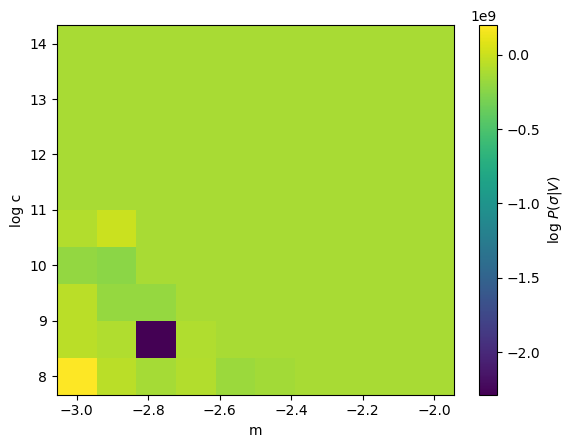

In [137]:
plt.pcolormesh(X, Y, F)
plt.xlabel("m")
plt.ylabel("log c")
plt.colorbar(label=r'log $P(\sigma|V)$')
plt.title("")
plt.show()

## Numerical Gradient

In [114]:
g_num_array = []
for i in arr:
        g_num_array.append(approx_derivative(f, i, method="3-point"))

......................................... Calculating likelihood with m, c, log(l):  -3.0 100000000.0 5
--- 10.012205839157104 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -3.000018166363357 100000000.0 5
--- 10.872190952301025 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -2.999981833636643 100000000.0 5
--- 9.715099334716797 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -3.0 99988846.06277508 5
--- 10.185075998306274 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -3.0 100011155.18146667 5
--- 10.912390232086182 seconds to calculate log_likelihood ---
......................................... Calculating likelihood with m, c, log(l):  -2.888888888888889 100000000.0 5
--- 10.

In [120]:
g_num_array = np.array(g_num_array)

In [121]:
df_dm = g_num_array[:, 0] * arr[:, 0]
df_dlogc = g_num_array[:, 1] * (10**(arr[:, 1]))

In [122]:
df_dlogc

array([ 2.71757000e+17,  1.01204245e+16,  1.07271796e+17,  8.80834695e+16,
       -1.02457606e+17, -2.89890873e+17, -1.03340453e+14,  4.34485492e+12,
        6.61796077e+14,  2.56132164e+13,  4.92607677e+16,  3.13475617e+17,
        7.17083495e+20,  1.07536975e+18,  3.13715705e+17, -7.87358823e+14,
        2.08596570e+13,  3.33512130e+15,  1.28210574e+14,  6.47028774e+12,
        2.69685000e+18,  4.31319799e+18,  7.69987707e+18,  5.03426692e+17,
        3.80983737e+15,  1.00071509e+14,  1.68172998e+16,  6.41888916e+14,
        3.19772773e+13,  7.00915522e+12,  8.75015467e+18, -1.78179483e+20,
        5.49918370e+18,  7.82980586e+16,  4.79908261e+14,  8.48541203e+16,
        3.21417062e+15,  1.58191044e+14,  3.29043368e+13,  2.86586859e+13,
        2.25599604e+20, -1.57754770e+23,  3.23734434e+16,  2.30130405e+15,
        4.28428415e+17,  1.60971174e+16,  7.83291941e+14,  1.54601763e+14,
        1.33053570e+14,  1.33271303e+14, -3.88066460e+21, -1.78409018e+19,
        1.10368635e+16,  

In [123]:
amp_df = np.hypot(df_dm.reshape(nx, ny), df_dlogc.reshape(nx, ny))

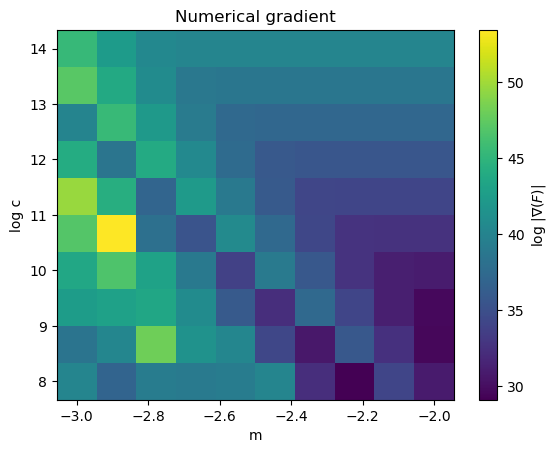

In [124]:
plt.pcolormesh(X, Y, np.log(amp_df))
plt.xlabel("m")
plt.ylabel("log c")
plt.colorbar(label=r'log $|\nabla(F)|$')
plt.title("Numerical gradient")
plt.show()

## Analytical Gradient

In [8]:
g = GM.gradient_m_log_posterior

In [9]:
g_an_array = []
for i in arr:
    g_an_array.append(g(i))

Calculating gradient of likelihood with m, c, l:  -3.0 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.888888888888889 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.7777777777777777 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.6666666666666665 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.5555555555555554 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.4444444444444446 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.3333333333333335 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.2222222222222223 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.111111111111111 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -2.0 100000000.0 100000
Calculating gradient of likelihood with m, c, l:  -3.0 464158883.3612773 100000
Calculating gradient of likelihood with m, c, l:  -2.888888888

In [10]:
g_an_array = np.array(g_an_array)

In [11]:
df_dm_an = g_an_array[:, 0] 
df_dlogc_an = g_an_array[:, 1] 

In [12]:
amp_df_an = np.hypot(df_dm_an.reshape(nx, ny), df_dlogc_an.reshape(nx, ny))

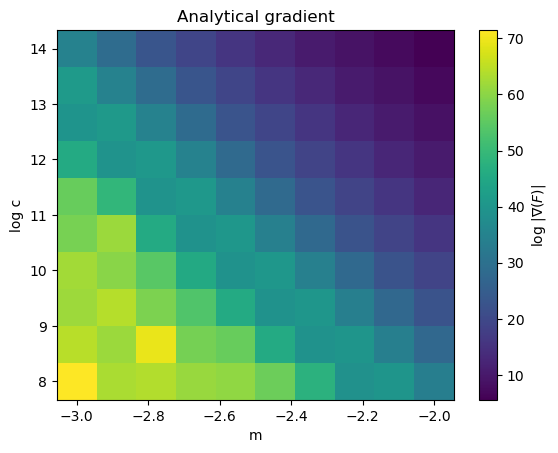

In [13]:
plt.pcolormesh(X, Y, np.log(amp_df_an))
plt.xlabel("m")
plt.ylabel("log c")
plt.colorbar(label=r'log $|\nabla(F)|$')
plt.title("Analytical gradient")
plt.show()

## Simple algorithm to try to find the maximum